In [3]:
#Problem Statement :Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets.
#importing the required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

#LSTM to process time series data , Dropout-Regularization technique to prevent overfitting

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [31]:
#importing the dataset sirectly from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vidhisrivastava/weather-dataset")

print("Path to dataset files:", path)

100%|██████████| 101k/101k [00:00<00:00, 304kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vidhisrivastava/weather-dataset/versions/1


In [32]:
import os

print(os.listdir(path))


['Project1WeatherDataset.csv']


In [33]:
# Load the CSV file into a Pandas DataFrame
file_path = os.path.join(path, "Project1WeatherDataset.csv")

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  
(8784, 8)
Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data c

In [34]:
#Check the data
print(df.isnull().sum())
print(df.describe())

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64
            Temp_C  Dew Point Temp_C    Rel Hum_%  Wind Speed_km/h  \
count  8784.000000       8784.000000  8784.000000      8784.000000   
mean      8.798144          2.555294    67.431694        14.945469   
std      11.687883         10.883072    16.918881         8.688696   
min     -23.300000        -28.500000    18.000000         0.000000   
25%       0.100000         -5.900000    56.000000         9.000000   
50%       9.300000          3.300000    68.000000        13.000000   
75%      18.800000         11.800000    81.000000        20.000000   
max      33.000000         24.400000   100.000000        83.000000   

       Visibility_km    Press_kPa  
count    8784.000000  8784.000000  
mean       27.664447   101.051623  
std        12.622688     0.844005  
min         0.200000    97.520000  


In [36]:
print(df.columns)

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')


In [38]:
# Convert the Date/Time column into datetime format and sort the data
df["Date/Time"] = pd.to_datetime(df["Date/Time"], errors="coerce")

df = df.sort_values("Date/Time")
df = df.dropna(subset=["Date/Time"])

print(df[["Date/Time"]].head())

            Date/Time
0 2012-01-01 00:00:00
1 2012-01-01 01:00:00
2 2012-01-01 02:00:00
3 2012-01-01 03:00:00
4 2012-01-01 04:00:00


In [39]:
df = df.sort_values("Date/Time")

# Select numerical features
features = [
    "Temp_C",
    "Dew Point Temp_C",
    "Rel Hum_%",
    "Wind Speed_km/h",
    "Visibility_km",
    "Press_kPa"
]

df = df[["Date/Time"] + features]

# Remove missing values
df = df.dropna()

print(df.head())
print(df.shape)

            Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0 2012-01-01 00:00:00    -1.8              -3.9         86                4   
1 2012-01-01 01:00:00    -1.8              -3.7         87                4   
2 2012-01-01 02:00:00    -1.8              -3.4         89                7   
3 2012-01-01 03:00:00    -1.5              -3.2         88                6   
4 2012-01-01 04:00:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa  
0            8.0     101.24  
1            8.0     101.24  
2            4.0     101.26  
3            4.0     101.27  
4            4.8     101.23  
(8784, 7)


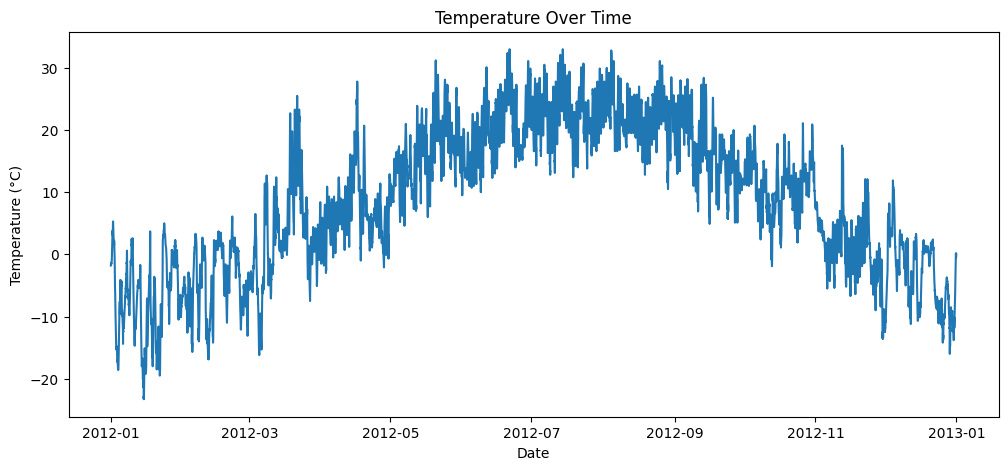

In [40]:
# Plot temperature over time to observe the time-series pattern
plt.figure(figsize=(12,5))

plt.plot(df["Date/Time"], df["Temp_C"])

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Over Time")

plt.show()

In [41]:
# Split the time-series data
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 7027
Testing samples: 1757


In [42]:
#Normalize the weather features to a range between 0 and 1
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

In [43]:
# Create sequences of the previous 24 hours to predict the temperature of the next hour
time_steps = 24

def create_sequences(data, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 0])   # Temp_C is first column

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7003, 24, 6)
y_train shape: (7003,)
X_test shape: (1733, 24, 6)
y_test shape: (1733,)


In [44]:
# Build an LSTM neural network
# dropout layers, and dense layers for temperature prediction
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
#Training the model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0189 - val_loss: 0.0020
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0062 - val_loss: 0.0027
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0046 - val_loss: 0.0013
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 9/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0018 - val_loss: 9.9250e-04
Epoch 10/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 11/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 12/30
197/197 ━━━━━━━━━━━━━━━━━

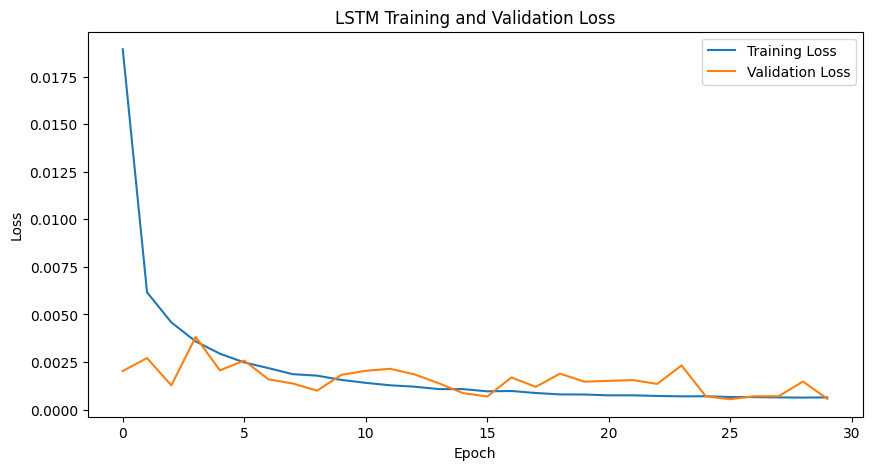

In [46]:
#Plotting training and validation loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [47]:
y_pred = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [48]:
# Convert the normalized temperature values back to the original
# temperature scale in degrees Celsius
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

y_test_actual = y_test * (temp_max - temp_min) + temp_min
y_pred_actual = y_pred.flatten() * (temp_max - temp_min) + temp_min

In [49]:
# Calculate Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)
# to measure the accuracy of the temperature predictions

mae = mean_absolute_error(y_test_actual, y_pred_actual)

rmse = np.sqrt(
    mean_squared_error(y_test_actual, y_pred_actual)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.9745096877019519
RMSE: 1.2417960087124436


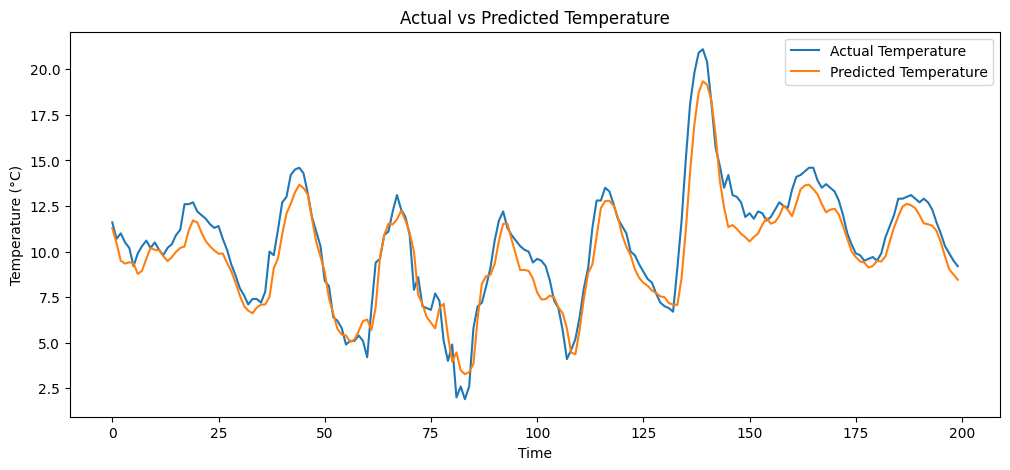

In [50]:
#comparing actual vs predicted temperature
plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual[:200],
    label="Actual Temperature"
)

plt.plot(
    y_pred_actual[:200],
    label="Predicted Temperature"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

plt.legend()
plt.show()

In [51]:
#predicting the next temperature
last_24_hours = test_scaled[-24:]

last_24_hours = last_24_hours.reshape(
    1,
    24,
    len(features)
)

next_temp_scaled = model.predict(last_24_hours)

next_temp = (
    next_temp_scaled[0][0] *
    (temp_max - temp_min) +
    temp_min
)

print("Predicted next temperature:", round(next_temp, 2), "°C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted next temperature: 0.33 °C
